# Record Audio From Microphone

In [ ]:
import sounddevice as sd
import numpy as np

duration = 5  # seconds
sampling_rate = 44100  # Hz
dtype = np.int32  # bitdepth

recording = sd.rec(
    duration * sampling_rate, samplerate=sampling_rate, channels=1, dtype=dtype
)
print("Recording...")
sd.wait()  # Wait until the recording is finished
print("Recording finished.")

Recording...
Recording finished.


In [2]:
print("audio data shape:", recording.shape)
print(recording[-10:])  # Print the last 10 samples of the recording

audio data shape: (220500, 1)
[[-0.0012207 ]
 [-0.00271606]
 [-0.00830078]
 [-0.0057373 ]
 [ 0.0007019 ]
 [-0.00085449]
 [-0.00265503]
 [ 0.00094604]
 [ 0.00436401]
 [ 0.0078125 ]]


In [3]:
sd.play(recording, samplerate=sampling_rate)

# Visualize Waveform and Spectrogram

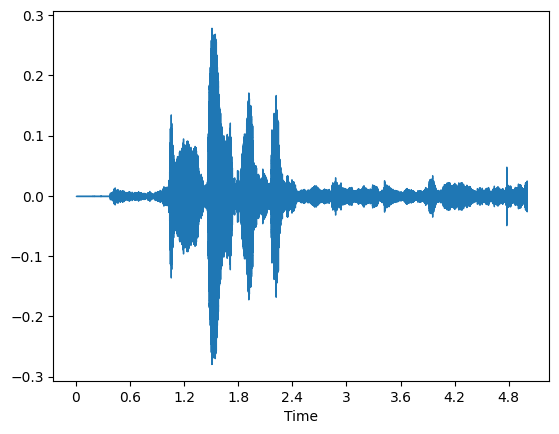

In [4]:
import librosa
import matplotlib.pyplot as plt

librosa.display.waveshow(recording.flatten(), sr=sampling_rate)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_36160\449675673.py:3: UserWarning: amplitude_to_db was called on complex input so phase information will be discarded. To suppress this warning, call amplitude_to_db(np.abs(S)) instead.
  D = librosa.amplitude_to_db(librosa.stft(recording.flatten()), ref=np.max)


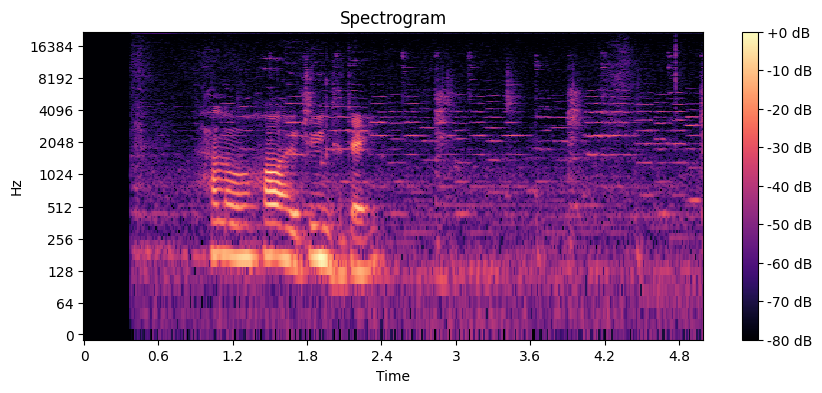

In [5]:
import numpy as np

D = librosa.amplitude_to_db(librosa.stft(recording.flatten()), ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(D, sr=sampling_rate, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

# Load and Write Audio File

In [ ]:
import soundfile as sf

sf.write("recoding.wav", recording, sampling_rate, subtype="PCM_24")

In [13]:
recording, sampling_rate = sf.read("recoding.wav")
print(recording.shape, sampling_rate)

(220500,) 44100


# Resample

In [ ]:
resampled_rate = 16000
resampled_recording = librosa.resample(
    recording.flatten(), orig_sr=sampling_rate, target_sr=resampled_rate
)
print(resampled_recording.shape)

(80000,)


In [15]:
sd.play(resampled_recording, samplerate=resampled_rate)